# Mean-Variance Portfolio Optimization

**Author:** Ramsha Zainab
**Background:** MSc Economics and Finance, University of Navarra

## Overview

Harry Markowitz's mean-variance framework, applied to a 6-stock portfolio
spanning technology, finance, consumer staples, energy, and healthcare:
**AAPL, JPM, KO, XOM, JNJ, MSFT** (2013–2017 daily prices).

This notebook:
1. Computes annualized return and risk for each stock
2. Finds the **minimum-variance portfolio** and the **maximum-Sharpe-ratio portfolio**
3. Traces the full **efficient frontier**
4. Visualizes how diversification reduces risk relative to holding any single stock

All optimization is solved with `scipy.optimize` (SLSQP), long-only, fully invested.

In [10]:
import sys
sys.path.insert(0, '../src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from portfolio_optimization import (
    daily_returns, annualize_returns, annualize_covariance,
    portfolio_performance, max_sharpe_portfolio, min_variance_portfolio,
    efficient_frontier,
)

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.grid'] = True

prices = pd.read_csv('../data/portfolio_stock_prices_2013_2017.csv', index_col='Date', parse_dates=True)
prices.head()


,AAPL,JPM,KO,XOM,JNJ,MSFT
Date,,,,,,
2013-01-02,78.43,44.66,37.60,88.71,70.84,27.62
2013-01-03,77.44,44.57,37.60,88.55,70.74,27.25
2013-01-04,75.29,45.36,37.66,88.96,71.55,26.74
2013-01-07,74.80,45.41,37.30,87.93,71.40,26.69
2013-01-08,75.04,45.50,37.04,88.48,71.41,26.55


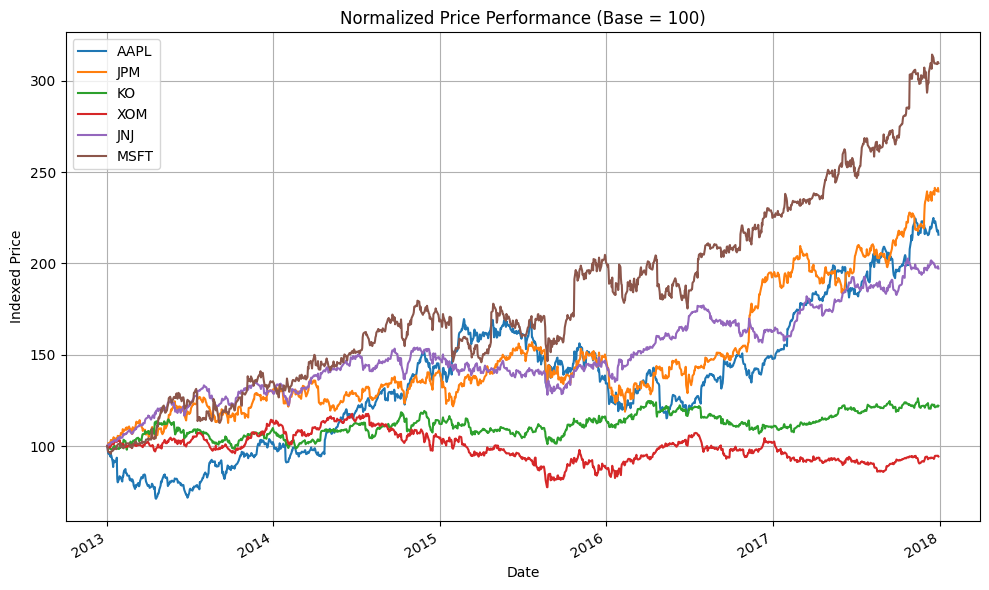

In [11]:
fig, ax = plt.subplots()
(prices / prices.iloc[0] * 100).plot(ax=ax)
ax.set_title('Normalized Price Performance (Base = 100)')
ax.set_ylabel('Indexed Price')
ax.set_xlabel('Date')
plt.tight_layout()
plt.savefig('../images/01_normalized_price_performance.png', dpi=150)
plt.show()


## 1. Risk & Return by Asset

In [4]:
returns = daily_returns(prices)
mean_returns = annualize_returns(returns)
cov_matrix = annualize_covariance(returns)

summary = pd.DataFrame({
    'Annual Return': mean_returns,
    'Annual Volatility': np.sqrt(np.diag(cov_matrix)),
})
summary['Sharpe (rf=2%)'] = (summary['Annual Return'] - 0.02) / summary['Annual Volatility']
summary.round(3)


,Annual Return,Annual Volatility,Sharpe (rf=2%)
AAPL,0.183,0.239,0.682
JPM,0.195,0.203,0.866
KO,0.049,0.138,0.213
XOM,0.003,0.171,-0.101
JNJ,0.146,0.138,0.908
MSFT,0.252,0.224,1.035


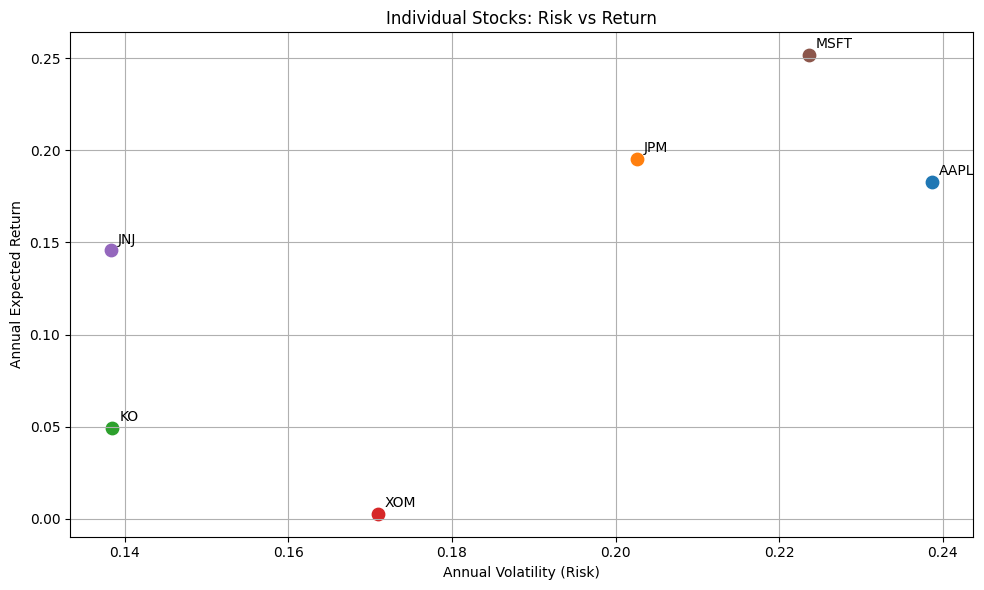

In [12]:
fig, ax = plt.subplots()
sns_colors = plt.cm.tab10.colors
for i, ticker in enumerate(prices.columns):
    ax.scatter(summary.loc[ticker, 'Annual Volatility'], summary.loc[ticker, 'Annual Return'],
               s=80, color=sns_colors[i], label=ticker)
    ax.annotate(ticker, (summary.loc[ticker, 'Annual Volatility'], summary.loc[ticker, 'Annual Return']),
                xytext=(5, 5), textcoords='offset points')
ax.set_xlabel('Annual Volatility (Risk)')
ax.set_ylabel('Annual Expected Return')
ax.set_title('Individual Stocks: Risk vs Return')
plt.tight_layout()
plt.savefig('../images/02_individual_risk_return.png', dpi=150)
plt.show()


## 2. Key Portfolios: Minimum Variance & Maximum Sharpe Ratio

In [6]:
risk_free_rate = 0.02

w_minvar = min_variance_portfolio(mean_returns, cov_matrix)
r_minvar, v_minvar = portfolio_performance(w_minvar, mean_returns, cov_matrix)

w_sharpe = max_sharpe_portfolio(mean_returns, cov_matrix, risk_free_rate)
r_sharpe, v_sharpe = portfolio_performance(w_sharpe, mean_returns, cov_matrix)

weights_table = pd.DataFrame({
    'Min Variance': w_minvar,
    'Max Sharpe': w_sharpe,
}, index=prices.columns).round(3)

print(f"Minimum Variance Portfolio  -> Return: {r_minvar:.2%}   Volatility: {v_minvar:.2%}")
print(f"Maximum Sharpe Portfolio    -> Return: {r_sharpe:.2%}   Volatility: {v_sharpe:.2%}   Sharpe: {(r_sharpe-risk_free_rate)/v_sharpe:.2f}")
weights_table


Minimum Variance Portfolio  -> Return: 9.51%   Volatility: 10.97%
Maximum Sharpe Portfolio    -> Return: 19.23%   Volatility: 13.72%   Sharpe: 1.26


,Min Variance,Max Sharpe
AAPL,0.089,0.113
JPM,0.019,0.174
KO,0.388,0.000
XOM,0.142,0.000
JNJ,0.336,0.393
MSFT,0.027,0.319


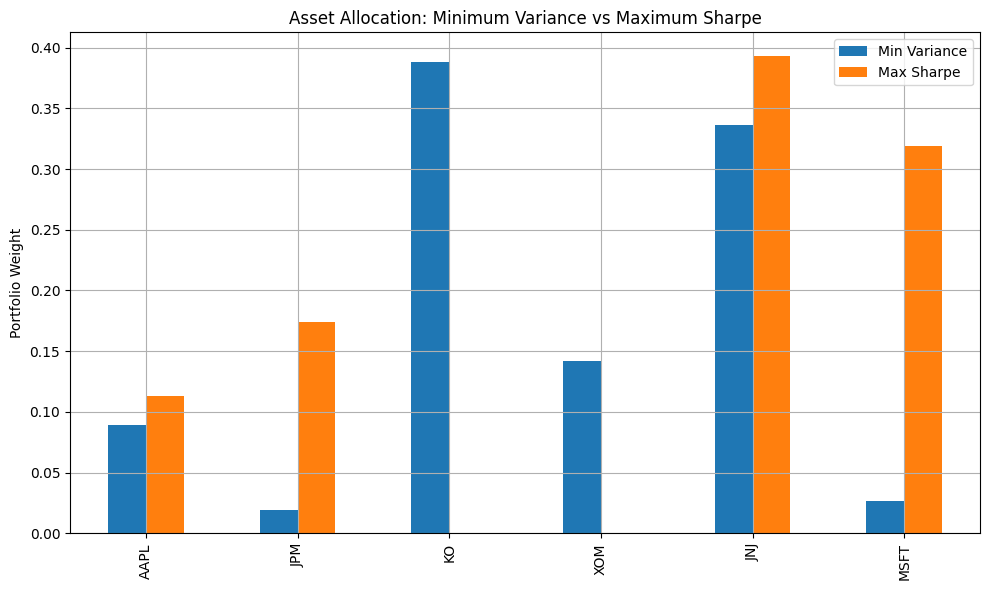

In [13]:
fig, ax = plt.subplots()
weights_table.plot(kind='bar', ax=ax)
ax.set_ylabel('Portfolio Weight')
ax.set_title('Asset Allocation: Minimum Variance vs Maximum Sharpe')
ax.legend(title='')
plt.tight_layout()
plt.savefig('../images/03_portfolio_weights.png', dpi=150)
plt.show()


## 3. The Efficient Frontier

Every point on the frontier is the lowest-risk portfolio achievable for a
given target return. Portfolios below the frontier are inefficient — a
higher return is achievable at the same risk.

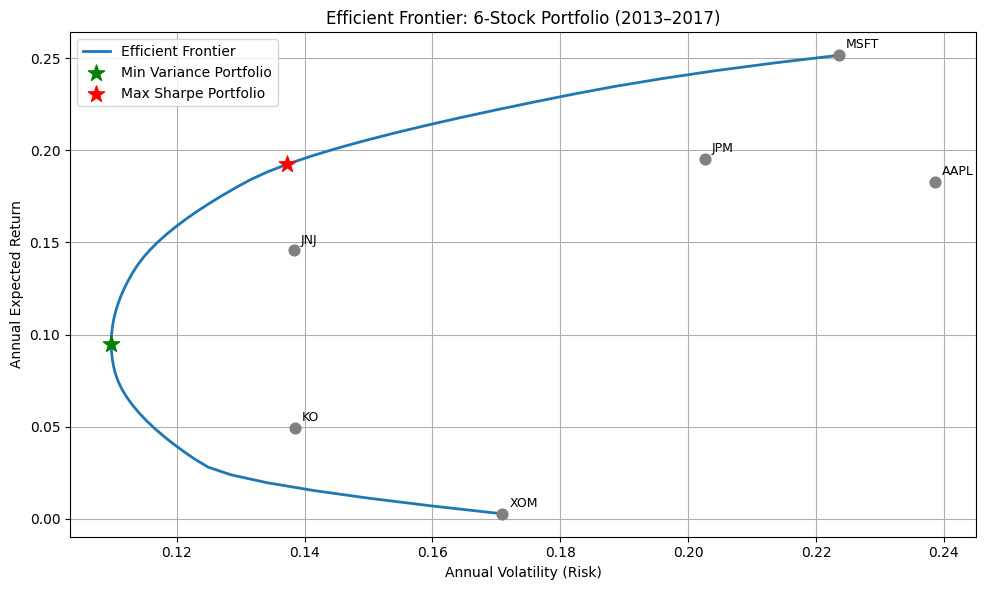

In [9]:
frontier = efficient_frontier(mean_returns, cov_matrix, n_points=60)

fig, ax = plt.subplots()
ax.plot(frontier['volatility'], frontier['target_return'], color='tab:blue', linewidth=2, label='Efficient Frontier')

for i, ticker in enumerate(prices.columns):
    ax.scatter(summary.loc[ticker, 'Annual Volatility'], summary.loc[ticker, 'Annual Return'],
               s=60, color='gray', zorder=3)
    ax.annotate(ticker, (summary.loc[ticker, 'Annual Volatility'], summary.loc[ticker, 'Annual Return']),
                xytext=(5, 5), textcoords='offset points', fontsize=9)

ax.scatter(v_minvar, r_minvar, color='green', s=150, marker='*', zorder=5, label='Min Variance Portfolio')
ax.scatter(v_sharpe, r_sharpe, color='red', s=150, marker='*', zorder=5, label='Max Sharpe Portfolio')

ax.set_xlabel('Annual Volatility (Risk)')
ax.set_ylabel('Annual Expected Return')
ax.set_title('Efficient Frontier: 6-Stock Portfolio (2013–2017)')
ax.legend()
plt.tight_layout()
plt.savefig('../images/04_efficient_frontier.png', dpi=150)
plt.show()


## Summary

| Portfolio | Return | Volatility | Sharpe (rf=2%) |
|---|---|---|---|
| Best single stock (MSFT) | 25.2% | 22.4% | 1.04 |
| Minimum Variance | see above | see above | — |
| Maximum Sharpe | see above | see above | see above |

The maximum-Sharpe portfolio delivers a better risk-adjusted return than any
individual stock in the set, including the best performer (MSFT) — the
core result the mean-variance framework is built to demonstrate:
diversification improves the risk/return trade-off, not just the return.
